<a href="https://colab.research.google.com/github/Lilycampbell0/Lily_Campbell_Portfolio/blob/main/Linear_Programming_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Programming Challenge

Consider the primal linear program

\begin{align*}
\text{maximize } ~~~11x_1 + 5x_2 & \\
\text{subject to } \phantom{~~11x_1 + 5x_2} &\\
x_1 + x_2 & \leq 7 \\
10x_1 + 4x_2 & \leq 40 \\
x_1, x_2 & \geq 0
\end{align*}

(a) Write the dual linear program.

(b) Find the solutions to both the primal and the dual linear programs and
  plot the feasible sets.  

(c) Does the dual price provide an accurate prediction of the
  increase in the primal objective function when the right-hand side
  of the first constraint is increased by 1?  By 2?  By 4?


In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from shapely.geometry import MultiPoint

Mounted at /content/drive


 matrix sol 47.000
y1 1.000
y2 1.000


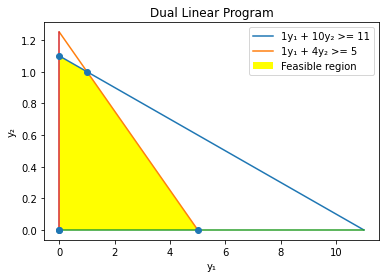

In [2]:
#Dual LP
A = np.array([
              [1, 10],
              [1, 4]
              ])

b = np.array([11, 5])
#c is taste matrix
c = np.array([7, 40])
# Here I define a 4-dimensional vector x, which I call x_vec
x_vec = cp.Variable(2)
objective = cp.Minimize(cp.sum(c.T @ x_vec))
#These constraints include the equity condition 
matrix_prob = cp.Problem(objective, constraints = [A@x_vec >= b, x_vec >=0])
matrix_solution = matrix_prob.solve()
print (" matrix sol {:.3f}".format(matrix_solution))
print("y1 {:.3f}".format(x_vec.value[0]))
print("y2 {:.3f}".format(x_vec.value[1]))

#feasible Set plot code
def feasible_vertices(A, b):
    """Returns the vertices of the feasible region."""
    candidates = [(0, 0)]
    for outer_idx in range(A.shape[0]):
        for inner_idx in range(outer_idx + 1, A.shape[0]):
            A_sub = [A[outer_idx], A[inner_idx]]
            b_sub = [b[outer_idx], b[inner_idx]]
            x_sub = np.linalg.solve(A_sub, b_sub)
            candidates.append(tuple(x_sub))
    for left, right in zip(A, b):
        x_intercept = right / left[0]
        y_intercept = right / left[1]
        candidates += [(0, y_intercept), (x_intercept, 0)]
    vertices = []
    for x, y in candidates:
        if x >= 0 and y >= 0 and np.all(A @ (x, y) <= b + 1e-8):
            vertices.append((x, y))
    return MultiPoint(vertices).convex_hull.exterior.xy

def plot_feasible_region(A, b):
    """Plots the feasible region."""
    hull = feasible_vertices(A, b)
    plt.fill(*hull, 'yellow', label='Feasible region')
    plt.scatter(*hull, marker='o', zorder=3)

def plot_constraints(A, b):
    """Plots constraints, including the non-negativity constraint."""
    x_max = 0
    y_max = 0
    for left, right in zip(A, b):
        x_intercept = right / left[0]
        y_intercept = right / left[1]
        plt.plot([0, x_intercept], [y_intercept, 0],
                 label=f'{left[0]}y₁ + {left[1]}y₂ >= {right}')
        x_max = max(x_max, x_intercept)
        y_max = max(y_max, y_intercept)
    plt.plot([0, x_max], [0, 0])
    plt.plot([0, 0], [0, y_max])
   #making the plot of the feasible sets 
plot_constraints(A, b) 
plot_feasible_region(A, b)   
plt.xlabel('y₁')
plt.ylabel('y₂')
plt.title('Dual Linear Program')
plt.legend()
plt.show()


 matrix sol 47.000
x1 2.000
x2 5.000


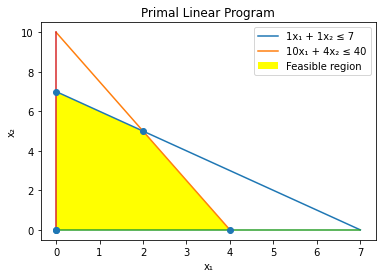

In [3]:
#Primal LP
A = np.array([
              [1, 1],
              [10, 4],
              ])

b = np.array([7,40])
#c is taste matrix
c = np.array([11, 5])
# Here I define a 4-dimensional vector x, which I call x_vec
x_vec = cp.Variable(2)
objective = cp.Maximize(cp.sum(c.T @ x_vec))
#These constraints include the equity condition 
matrix_prob = cp.Problem(objective, constraints = [A@x_vec <= b, x_vec >=0])
matrix_solution = matrix_prob.solve()
print (" matrix sol {:.3f}".format(matrix_solution))
print("x1 {:.3f}".format(x_vec.value[0]))
print("x2 {:.3f}".format(x_vec.value[1]))

#Ploting the Feasible set
def feasible_vertices(A, b):
    """Returns the vertices of the feasible region."""
    candidates = [(0, 0)]
    for outer_idx in range(A.shape[0]):
        for inner_idx in range(outer_idx + 1, A.shape[0]):
            A_sub = [A[outer_idx], A[inner_idx]]
            b_sub = [b[outer_idx], b[inner_idx]]
            x_sub = np.linalg.solve(A_sub, b_sub)
            candidates.append(tuple(x_sub))
    for left, right in zip(A, b):
        x_intercept = right / left[0]
        y_intercept = right / left[1]
        candidates += [(0, y_intercept), (x_intercept, 0)]
    vertices = []
    for x, y in candidates:
        if x >= 0 and y >= 0 and np.all(A @ (x, y) <= b + 1e-8):
            vertices.append((x, y))
    return MultiPoint(vertices).convex_hull.exterior.xy

def plot_feasible_region(A, b):
    """Plots the feasible region."""
    hull = feasible_vertices(A, b)
    plt.fill(*hull, 'yellow', label='Feasible region')
    plt.scatter(*hull, marker='o', zorder=3)

def plot_constraints(A, b):
    """Plots constraints, including the non-negativity constraint."""
    x_max = 0
    y_max = 0
    for left, right in zip(A, b):
        x_intercept = right / left[0]
        y_intercept = right / left[1]
        plt.plot([0, x_intercept], [y_intercept, 0],
                 label=f'{left[0]}x₁ + {left[1]}x₂ ≤ {right}')
        x_max = max(x_max, x_intercept)
        y_max = max(y_max, y_intercept)
    plt.plot([0, x_max], [0, 0])
    plt.plot([0, 0], [0, y_max])
   #making the plot of the feasible sets 
plot_constraints(A, b) 
plot_feasible_region(A, b)   
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Primal Linear Program')
plt.legend()
plt.show()